In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import pickle as pkl
import os

## aux func

In [ ]:
def plot_results(data, return_plot = False):
    fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(12, 4))

    y_min_delta = np.inf
    y_max_delta = -np.inf

    for key, value in data.items():
        value["delta_diff"] = np.abs(value["delta"] - value["delta_real"])
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
        y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
        y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
        y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())

        axs[0].plot(df_mean.index, df_mean["bank_cash"], label=key)
        axs[0].fill_between(df_mean.index, df_mean["bank_cash"] - df_std["bank_cash"], df_mean["bank_cash"] + df_std["bank_cash"], alpha=0.2)
        axs[0].set_title("Bank Cash")
        axs[0].set_ylabel("Bank Cash")


        axs[1].plot(df_mean.index, df_mean["delta"], label=key)
        axs[1].fill_between(df_mean.index, df_mean["delta"] - df_std["delta"], df_mean["delta"] + df_std["delta"], alpha=0.2)
        axs[1].set_title("$\\tilde \\Delta$")
        axs[1].set_ylabel("$\\tilde \\Delta$")

        axs[2].plot(df_mean.index, df_mean["delta_real"], label=key)
        axs[2].fill_between(df_mean.index, df_mean["delta_real"] - df_std["delta_real"], df_mean["delta_real"] + df_std["delta_real"], alpha=0.2)
        axs[2].set_title("$\\Delta$")
        axs[2].set_ylabel("$\\Delta$")

        axs[3].plot(df_mean.index, df_mean["delta_diff"], label=key)
        axs[3].fill_between(df_mean.index, df_mean["delta_diff"] - df_std["delta_diff"], df_mean["delta_diff"] + df_std["delta_diff"], alpha=0.2)
        axs[3].set_title("$|\\Delta - \\tilde \\Delta|$")
    
    for i in range(1, 4):
        # draw y=0 line
        axs[i].axhline(0, color='#606060', lw=1, ls='--')

    for i in range(4):
        axs[i].set_xlabel("Time step")
        axs[i].legend()

    #for i in range(1, 3):
    #    axs[i].set_ylim(y_min_delta, y_max_delta)
    if return_plot:
        return fig, axs
    else:
        plt.tight_layout()
        plt.show()

In [255]:
def plot_correct_predictions(data):
    fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(15, 4))

    y_min_delta = np.inf
    y_max_delta = -np.inf

    table = []
    for key, value in data.items():
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
        y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
        y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
        y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())

        # plot cunsum of label
        axs[0].plot(df_mean.index, np.cumsum(df_mean["label"]), label=key)
        axs[0].set_title("Percentage of positive labes")
        axs[0].set_ylabel("Percentage of positive labels")

        # plot cunsum of prediction
        axs[1].plot(df_mean.index, np.cumsum(df_mean["pred"]), label=key)
        axs[1].set_title("Percentage of positive predictions")
        axs[1].set_ylabel("Percentage of positive predictions")

        # plot cunsum of correct predictions
        axs[2].plot(df_mean.index, np.cumsum(df_mean["correct"]), label=key)
        axs[2].set_title("Percentage of correct predictions")
        axs[2].set_ylabel("Percentage of correct predictions")

        # plot the gap between delta and delta_real
        axs[3].plot(df_mean.index, np.abs(df_mean["delta_real"] - df_mean["delta"]), label=key)
        axs[3].set_title("Gap between $\\Delta$ and $\\tilde \\Delta$")
        axs[3].set_ylabel("Gap between $\\Delta$ and $\\tilde \\Delta$")

        df_sum = value.groupby("ep").mean().mean()
        table.append({
            "method": key,
            "C obs" : df_sum["delta"],
            "C real" : df_sum["delta_real"],
            "C diff" : np.abs(df_sum["delta"] - df_sum["delta_real"]),
        })


    # on axis 3, plot a horizontal line at 0
    axs[3].axhline(0, color='black', linestyle='--')
    
    for i in range(4):
        axs[i].set_xlabel("Time step")
        axs[i].legend()

    #for i in range(1, 3):
    #    axs[i].set_ylim(y_min_delta, y_max_delta)

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(table)
    print(table)

In [50]:
def confusion_matrix(data):

    for key, value in data.items():
        cm = np.zeros((2, 2))
        # do only in episode 0
        value = value[value["ep"] == 0]
        cm[0][0] = value[(value["label"] == 0) & (value["pred"] == 0)].shape[0]
        cm[0][1] = value[(value["label"] == 0) & (value["pred"] == 1)].shape[0]
        cm[1][0] = value[(value["label"] == 1) & (value["pred"] == 0)].shape[0]
        cm[1][1] = value[(value["label"] == 1) & (value["pred"] == 1)].shape[0]

        print(key)
        print(f"TP: {cm[1][1]}")
        print(f"TN: {cm[0][0]}")
        print(f"FP: {cm[0][1]}")
        print(f"FN: {cm[1][0]}")

In [40]:
def plot_group_metrics(data):
    data = data[data["ep"] == 0]
    #data = data.groupby(["group_id", "t"]).mean().reset_index()

    for g in [0, 1]:
        data_g = data[data["group_id"] == g]
        accepted = np.cumsum(data_g["action"]) / len(data_g)
        plt.plot(data_g["t"], accepted, label=f"Group {g}")
    
    plt.legend()
    plt.title("Accepted individuas")
    plt.show()



In [202]:
def plot_mu(data):
    fig, axs = plt.subplots(nrows = len(data), ncols = 1, figsize = (8, int(len(data) * 4)))

    if len(data) == 1:
        axs = [axs]
    i = 0
    for key, value in data.items():
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        axs[i].plot(df_mean.index, df_mean["mu0"], label=key)
        axs[i].fill_between(df_mean.index, df_mean["mu0"] - df_std["mu0"], df_mean["mu0"] + df_std["mu0"], alpha=0.2)

        axs[i].plot(df_mean.index, df_mean["mu1"], label=key)
        axs[i].fill_between(df_mean.index, df_mean["mu1"] - df_std["mu1"], df_mean["mu1"] + df_std["mu1"], alpha=0.2)

        axs[i].set_title(key)
        axs[i].set_ylabel("Mu")
        axs[i].set_xlabel("Time step")
        i += 1


    plt.tight_layout()
    plt.show()

In [ ]:
def plot_theorem_metrics()

In [ ]:
from collections import deque
df = pd.read_csv("experiments/yu2022/sellf/eval/eval_data.csv")

df =df[df["ep"] == 1]

window_size = 300

group_data = {
    "action" : [deque(maxlen=window_size), deque(maxlen=window_size)],
    "error" : [deque(maxlen=window_size), deque(maxlen=window_size)],
}

acceptance_data = [[], []]
error_data = [[], []]
for i, row in df.iterrows():
    group_data["action"][int(row["group_id"])].append(row["action"])
    group_data["error"][int(row["group_id"])].append(row["pred"] - row["label"])


    for g in [0, 1]:
        if len(group_data["error"][g]) == window_size:
            acceptance_data[g].append(np.mean(group_data["action"][g]))
            error_data[g].append(np.mean(group_data["error"][g]))
        else:
            # append nan
            acceptance_data[g].append(np.nan)
            error_data[g].append(np.nan)

# replace nan with the closest non nan value
for g in [0, 1]:
    acceptance_data[g] = pd.Series(acceptance_data[g]).interpolate(method='linear', limit_direction='both').to_numpy()
    error_data[g] = pd.Series(error_data[g]).interpolate(method='linear', limit_direction='both').to_numpy()

new_df = pd.DataFrame({
    "acceptance_0" : acceptance_data[0],
    "acceptance_1" : acceptance_data[1],
    "error_0" : error_data[0],
    "error_1" : error_data[1],
    "t" : df["t"],
})





In [447]:
from collections import deque
df = pd.read_csv("experiments/yu2022/sellf/eval/eval_data.csv")


def preprocess_ep_data(df):
    window_size = 300

    group_data = {
        "action" : [deque(maxlen=window_size), deque(maxlen=window_size)],
        "error" : [deque(maxlen=window_size), deque(maxlen=window_size)],
    }

    acceptance_data = [[], []]
    error_data = [[], []]
    for i, row in df.iterrows():
        group_data["action"][int(row["group_id"])].append(row["action"])
        group_data["error"][int(row["group_id"])].append(row["pred"] - row["label"])


        for g in [0, 1]:
            if len(group_data["error"][g]) == window_size:
                acceptance_data[g].append(np.mean(group_data["action"][g]))
                error_data[g].append(np.mean(group_data["error"][g]))
            else:
                # append nan
                acceptance_data[g].append(np.nan)
                error_data[g].append(np.nan)

    # replace nan with the closest non nan value
    for g in [0, 1]:
        acceptance_data[g] = pd.Series(acceptance_data[g]).interpolate(method='linear', limit_direction='both').to_numpy()
        error_data[g] = pd.Series(error_data[g]).interpolate(method='linear', limit_direction='both').to_numpy()

    new_df = pd.DataFrame({
        "acceptance_0" : acceptance_data[0],
        "acceptance_1" : acceptance_data[1],
        "error_0" : error_data[0],
        "error_1" : error_data[1],
        "t" : df["t"],
    })
    return new_df



df = df.groupby("ep", group_keys=False).apply(preprocess_ep_data)
df = df.groupby("t").mean()

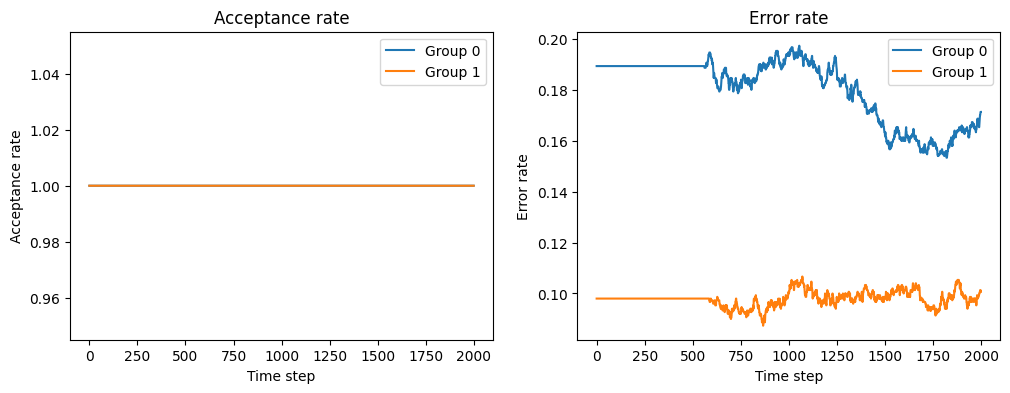

In [448]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 4))
axs[0].plot(df.acceptance_0, label="Group 0")
axs[0].plot(df.acceptance_1, label="Group 1")

axs[0].set_title("Acceptance rate")
axs[0].set_ylabel("Acceptance rate")
axs[0].set_xlabel("Time step")

axs[0].legend()

axs[1].plot(df.error_0, label="Group 0")
axs[1].plot(df.error_1, label="Group 1")
axs[1].set_title("Error rate")
axs[1].set_ylabel("Error rate")
axs[1].set_xlabel("Time step")

axs[1].legend()

Text(0.5, 1.0, 'Error rate')

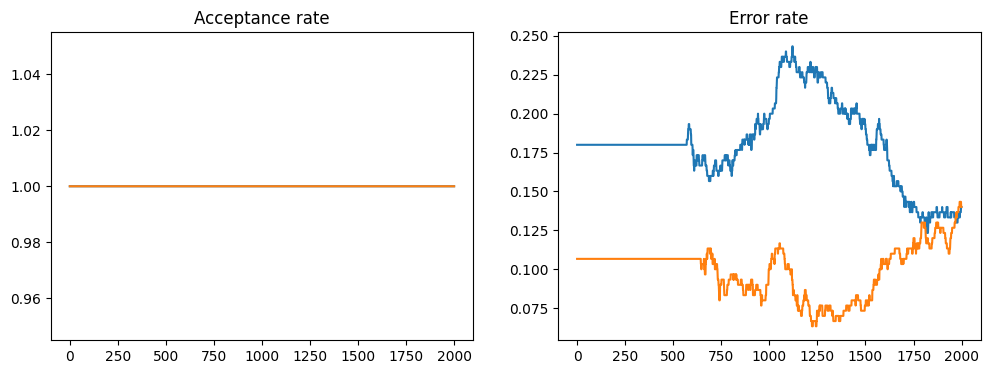

In [444]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 4))
axs[0].plot(acceptance_data[0], label="Group 0")
axs[0].plot(acceptance_data[1], label="Group 1")

axs[0].set_title("Acceptance rate")

axs[1].plot(error_data[0], label="Group 0")
axs[1].plot(error_data[1], label="Group 1")
axs[1].set_title("Error rate")



## results

In [298]:
env = "fico"
model_list = ["ppo", "pocar", "sellf", "sellf_v2"] # "sellf_v1",
model_list = ["sellf_tpr", "pocar_tpr", "ppo_tpr",] # "sellf_tpr_v2", "sellf_tpr_v3"]
model_folders = [f"experiments/{env}/{model}/eval/eval_data.csv" for model in model_list]
data = {}
for folder in model_folders:
    model_name = folder.split("/")[-3]
    data[model_name] = pd.read_csv(folder)

In [ ]:
colors = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854']
method_names = {
    "ppo_tpr" : "PPO",
    "sellf_tpr" : "Sellf",
    "pocar_tpr" : "Pocar",
}
method_colors = dict(zip(model_list, colors))

{'sellf_tpr': '#66c2a5', 'pocar_tpr': '#fc8d62', 'ppo_tpr': '#8da0cb'}

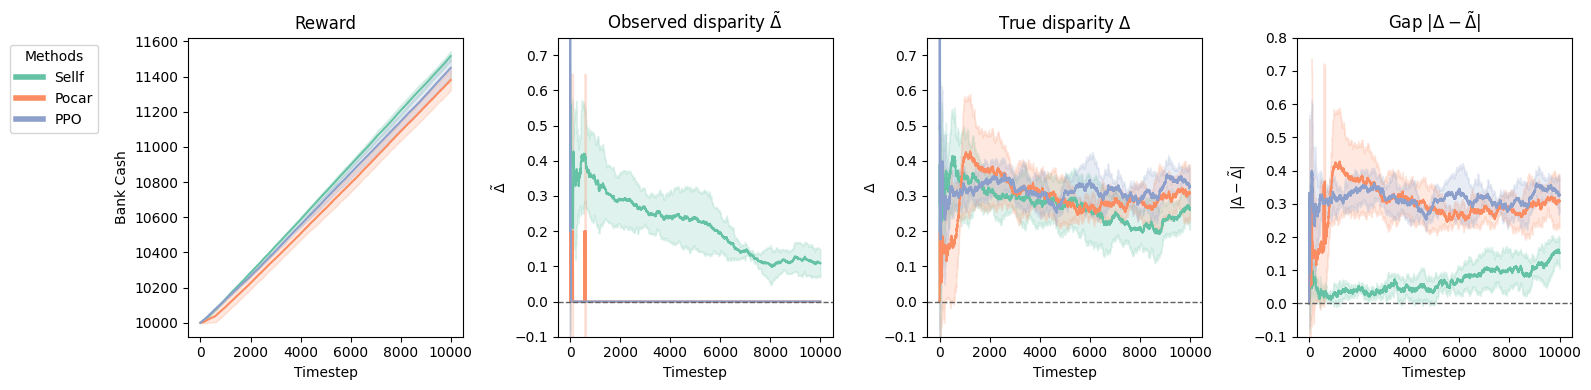

In [327]:
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(16, 4))

y_min_delta = np.inf
y_max_delta = -np.inf

for key, value in data.items():
    value["delta_diff"] = np.abs(value["delta"] - value["delta_real"])
    df_mean = value.groupby("t").mean()
    df_std = value.groupby("t").std()

    y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
    y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
    y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
    y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())

    for i, col in enumerate(["bank_cash", "delta", "delta_real", "delta_diff"]):
        axs[i].plot(df_mean.index, df_mean[col], label=key, color=method_colors[key])
        axs[i].fill_between(df_mean.index, df_mean[col] - df_std[col], df_mean[col] + df_std[col], alpha=0.2, color=method_colors[key])


    #axs[0].plot(df_mean.index, df_mean["bank_cash"], label=key, color=method_colors[key])
    #axs[0].fill_between(df_mean.index, df_mean["bank_cash"] - df_std["bank_cash"], df_mean["bank_cash"] + df_std["bank_cash"], alpha=0.2, color=method_colors[key])
    axs[0].set_title("Reward")
    axs[0].set_ylabel("Bank Cash")

    #axs[1].plot(df_mean.index, df_mean["delta"], label=key, color=method_colors[key])
    #axs[1].fill_between(df_mean.index, df_mean["delta"] - df_std["delta"], df_mean["delta"] + df_std["delta"], alpha=0.2, color=method_colors[key])
    axs[1].set_title("Observed disparity $\\tilde \\Delta$")
    axs[1].set_ylabel("$\\tilde \\Delta$")

    #axs[2].plot(df_mean.index, df_mean["delta_real"], label=key, color=method_colors[key])
    #axs[2].fill_between(df_mean.index, df_mean["delta_real"] - df_std["delta_real"], df_mean["delta_real"] + df_std["delta_real"], alpha=0.2, color=method_colors[key])
    axs[2].set_title("True disparity $\\Delta$")
    axs[2].set_ylabel("$\\Delta$")

    #axs[3].plot(df_mean.index, df_mean["delta_diff"], label=key, color=method_colors[key])
    #axs[3].fill_between(df_mean.index, df_mean["delta_diff"] - df_std["delta_diff"], df_mean["delta_diff"] + df_std["delta_diff"], alpha=0.2, color=method_colors[key])
    axs[3].set_title("Gap $|\\Delta - \\tilde \\Delta|$")
    axs[3].set_ylabel("$|\\Delta - \\tilde \\Delta|$")

for i in range(1, 4):
    # draw y=0 line
    axs[i].axhline(0, color='#606060', lw=1, ls='--')

for i in range(4):
    axs[i].set_xlabel("Timestep")

for i in range(1, 3):
    axs[i].set_ylim(-0.1, 0.75)

axs[3].set_ylim(-0.1, 0.8)

handles = [
    plt.Line2D([0], [0], color=method_colors[key], lw=4) for key in data.keys()
]
axs[0].legend(handles, [method_names[key] for key in data.keys()], loc='upper right', bbox_to_anchor=(-0.3, 1), title="Methods", fontsize=10)


plt.tight_layout()
plt.savefig("fico_results.pdf", bbox_inches='tight')
plt.show()

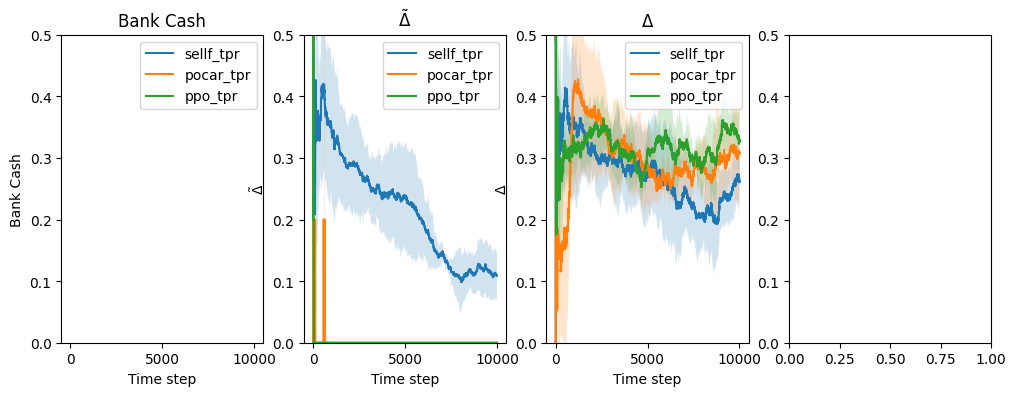

In [308]:
for ax in axs:
    ax.set_ylim(0, 0.5)

fig

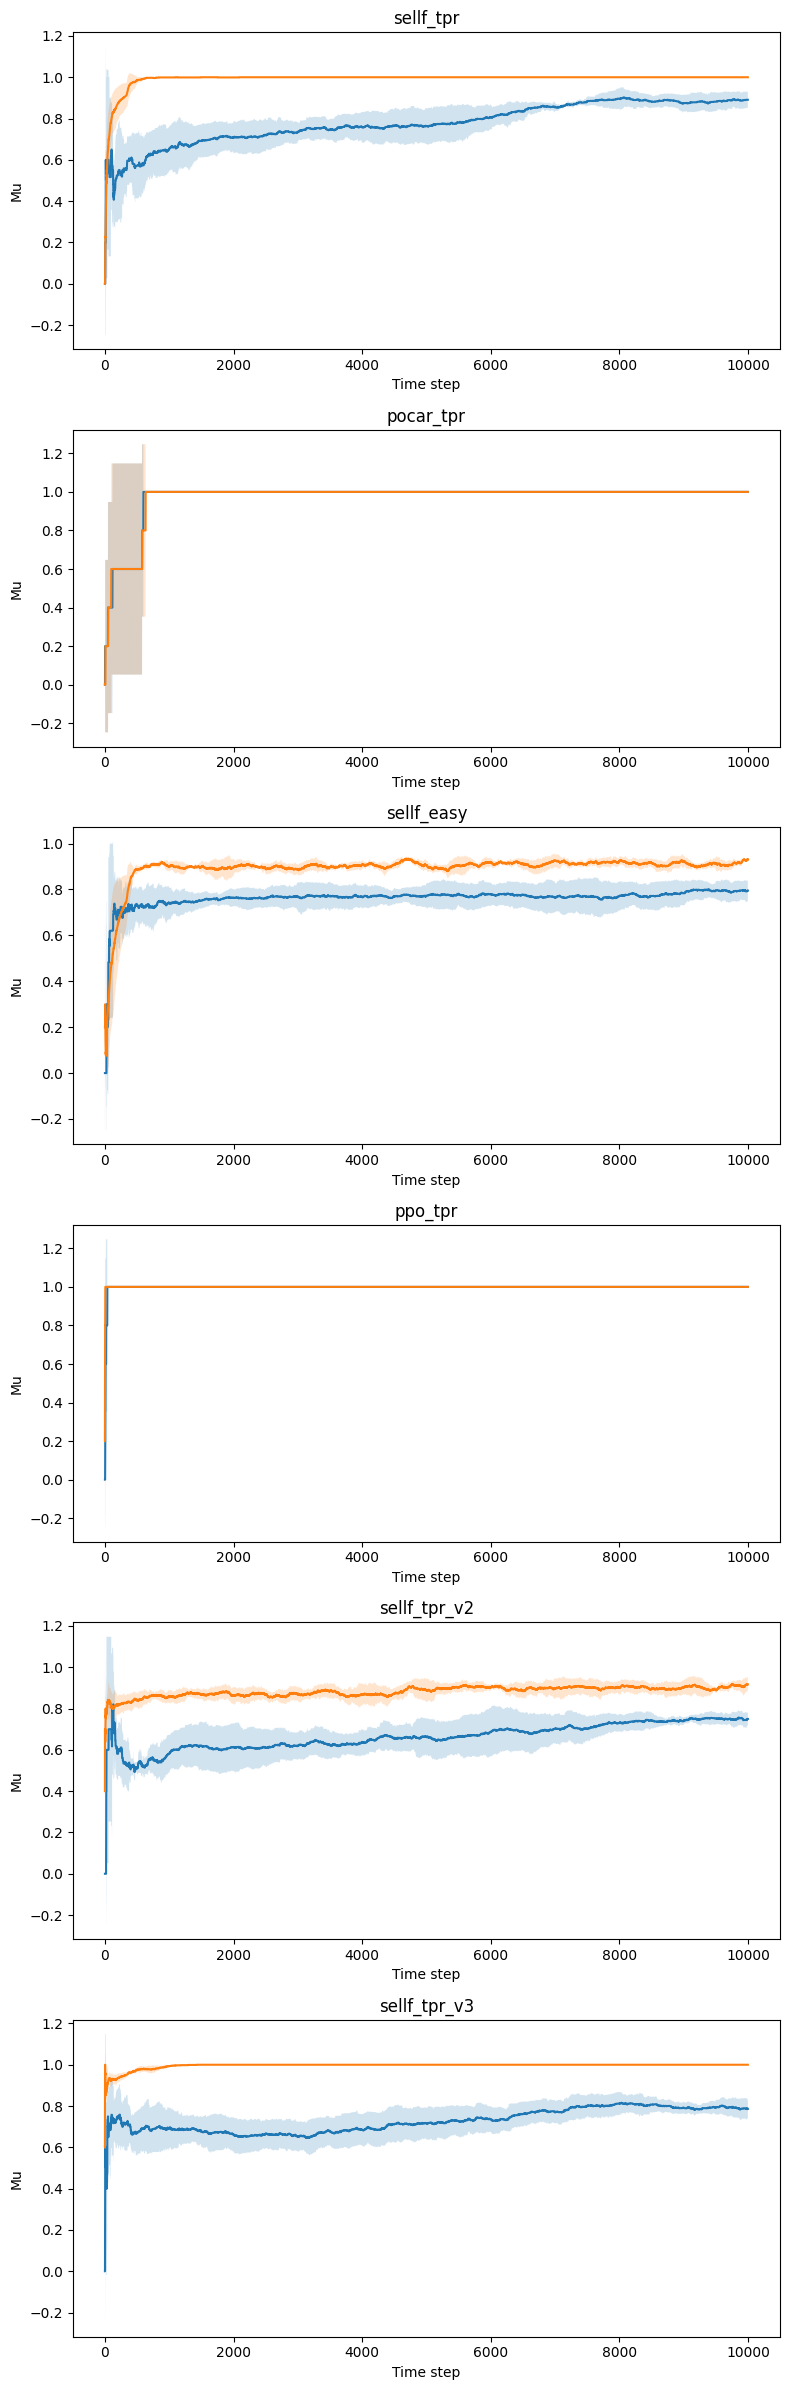

In [251]:
plot_mu(data)

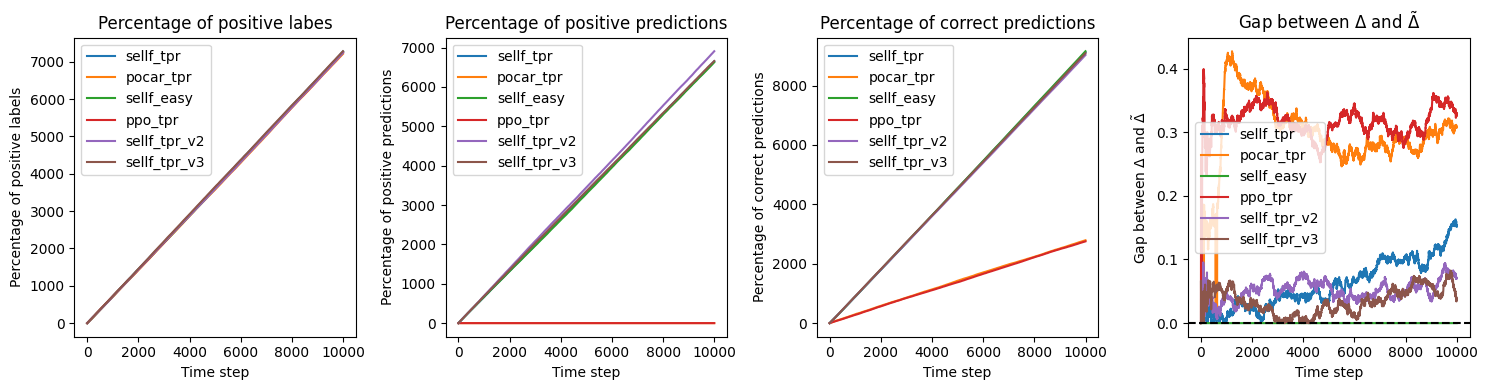

         method     C obs    C real    C diff
0     sellf_tpr  0.216791  0.275346  0.058555
1     pocar_tpr  0.001300  0.297219  0.295919
2    sellf_easy  0.136828  0.136828  0.000000
3       ppo_tpr  0.001360  0.316621  0.315261
4  sellf_tpr_v2  0.223852  0.274762  0.050910
5  sellf_tpr_v3  0.268502  0.281043  0.012540


In [256]:
plot_correct_predictions(data)

In [232]:
confusion_matrix(data)

sellf_tpr
TP: 7046.0
TN: 2173.0
FP: 441.0
FN: 340.0
pocar_tpr
TP: 0.0
TN: 2702.0
FP: 0.0
FN: 7298.0
sellf_easy
TP: 6367.0
TN: 2694.0
FP: 110.0
FN: 829.0
ppo_tpr
TP: 0.0
TN: 2761.0
FP: 0.0
FN: 7239.0


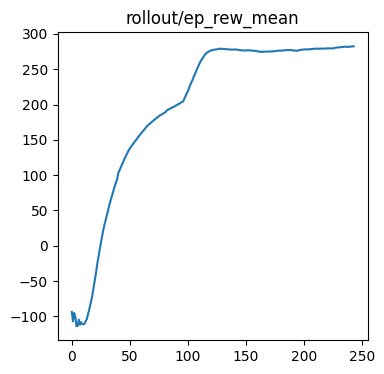

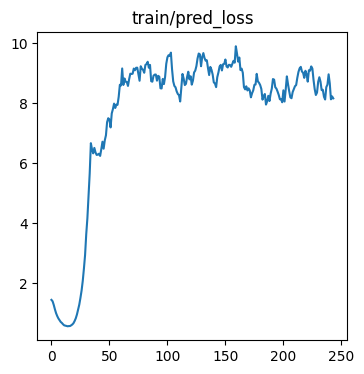

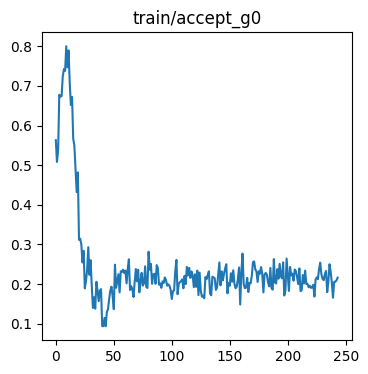

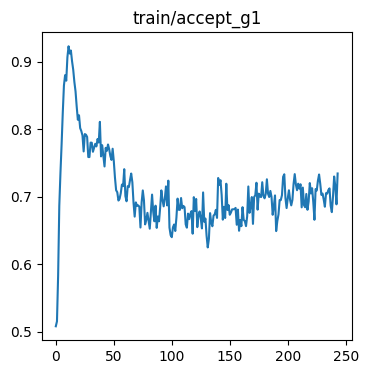

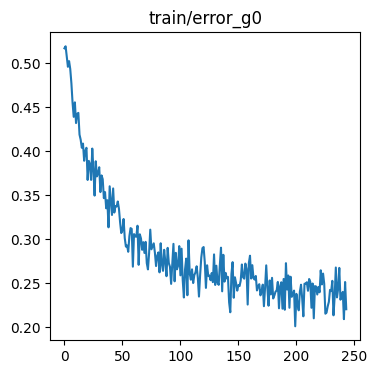

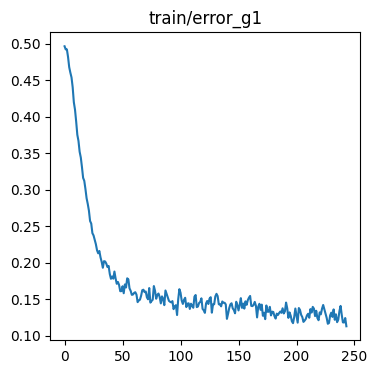

In [266]:
df_log = pd.read_csv("experiments/fico/sellf_tpr/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    #"train/pred_loss_g0",
    #"train/pred_loss_g1",
    #"train/accept_rate",
    #"train/pos_rate",
    "train/accept_g0",
    "train/accept_g1",
    "train/error_g0",
    "train/error_g1",
]

for col in columns:
    fig = plt.figure(figsize=(4, 4))

    val = df_log[col].values
    # if there is a nan value, replace it with the previous value
    new_val = []
    for i in range(1, len(val)):
        if np.isnan(val[i]):
            new_val.append(new_val[-1])
        else:
            new_val.append(val[i])
    
    plt.plot(new_val, label=col)
    plt.title(col)
    plt.show()


In [261]:
enem.keys()

dict_keys(['group_likelihoods', 'cluster_probabilities', 'success_probabilities'])

In [265]:
enem = pkl.load(open("data/enem.pkl", "rb"))
sum(enem["success_probabilities"][0])

3.3296925008276683

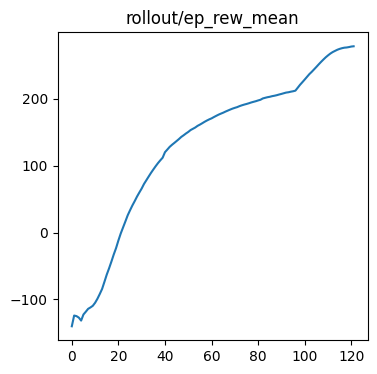

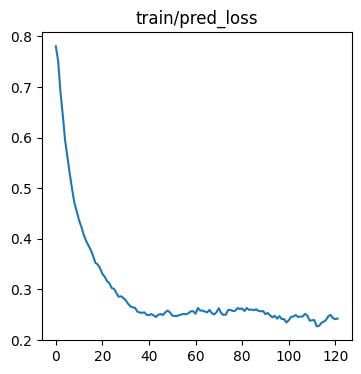

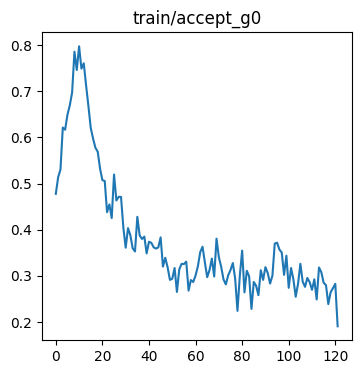

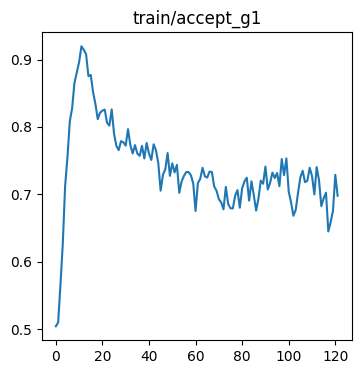

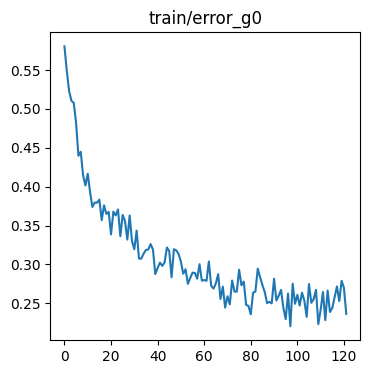

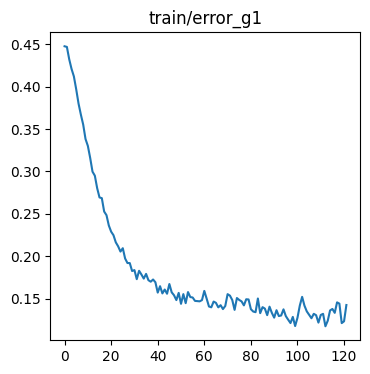

In [226]:
df_log = pd.read_csv("experiments/fico/sellf_easy/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    #"train/pred_loss_g0",
    #"train/pred_loss_g1",
    #"train/accept_rate",
    #"train/pos_rate",
    "train/accept_g0",
    "train/accept_g1",
    "train/error_g0",
    "train/error_g1",
]

for col in columns:
    fig = plt.figure(figsize=(4, 4))

    val = df_log[col].values
    # if there is a nan value, replace it with the previous value
    new_val = []
    for i in range(1, len(val)):
        if np.isnan(val[i]):
            new_val.append(new_val[-1])
        else:
            new_val.append(val[i])
    
    plt.plot(new_val, label=col)
    plt.title(col)
    plt.show()


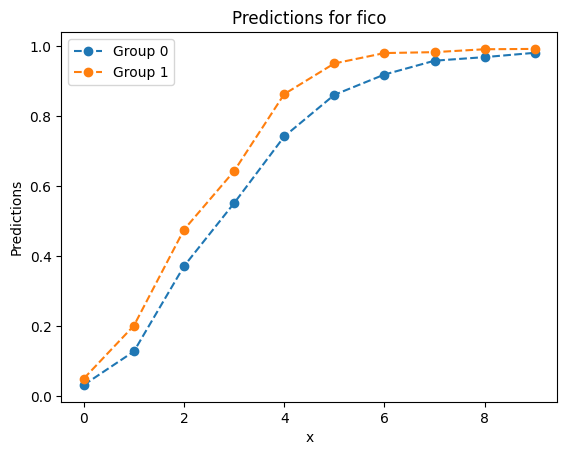

In [242]:
for env in ["fico"]:
    preds = {}
    model_folders = glob(f"experiments/{env}/sellf_tpr/eval/predictions.csv")
    for folder in model_folders:
        model_name = folder.split("/")[-3]
        preds[model_name] = pd.read_csv(folder)

    for df in preds.values():
        for g in range(2):
            df_ = df[df.g == g]
            df_ = df_.sort_values("x")
            plt.plot(df_.x, df_.pred, label=f"Group {g}", marker="o", linestyle="--")
    plt.title(f"Predictions for {env}")
    plt.xlabel("x")
    plt.ylabel("Predictions")
    plt.legend()
    plt.show()

## ENEM

In [335]:
env = "enem"
model_list = ["ppo_tpr", "sellf_tpr", "pocar_tpr", "ppo_tpr", "sellf_tpr_v2", "sellf_tpr_v3"]
model_folders = [f"experiments/{env}/{model}/eval/eval_data.csv" for model in model_list]
data = {}
for folder in model_folders:
    model_name = folder.split("/")[-3]
    data[model_name] = pd.read_csv(folder)

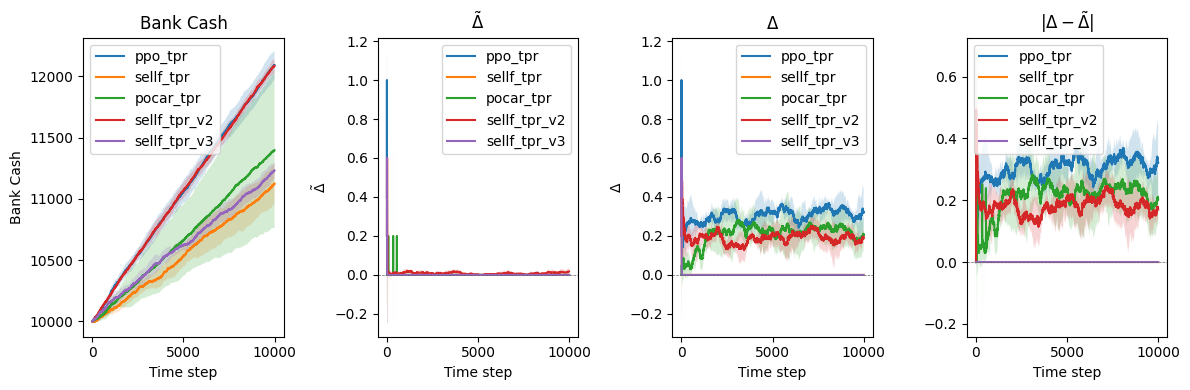

In [336]:
plot_results(data)

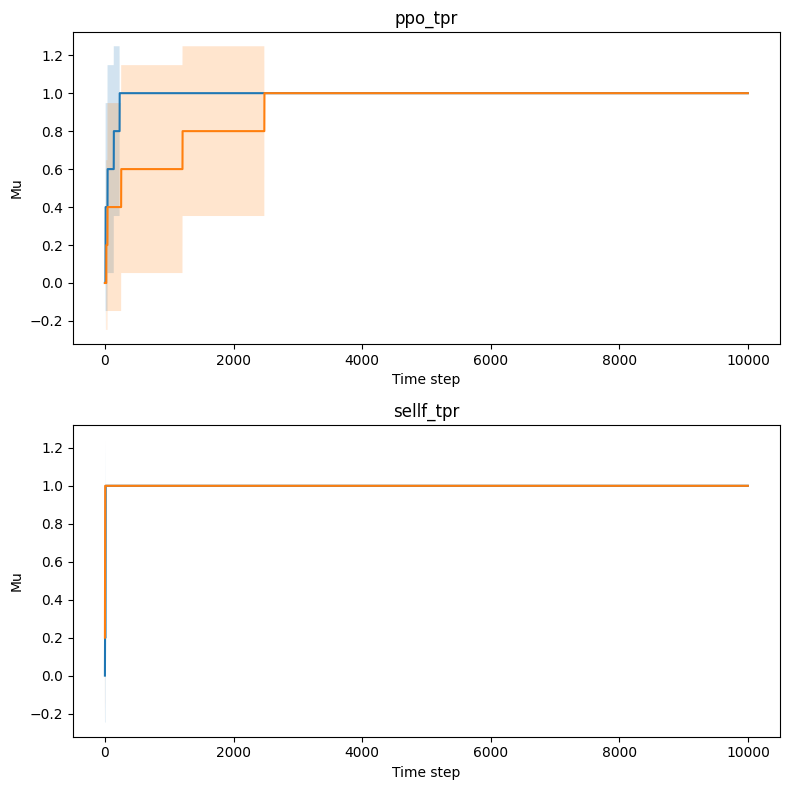

In [296]:
plot_mu(data)

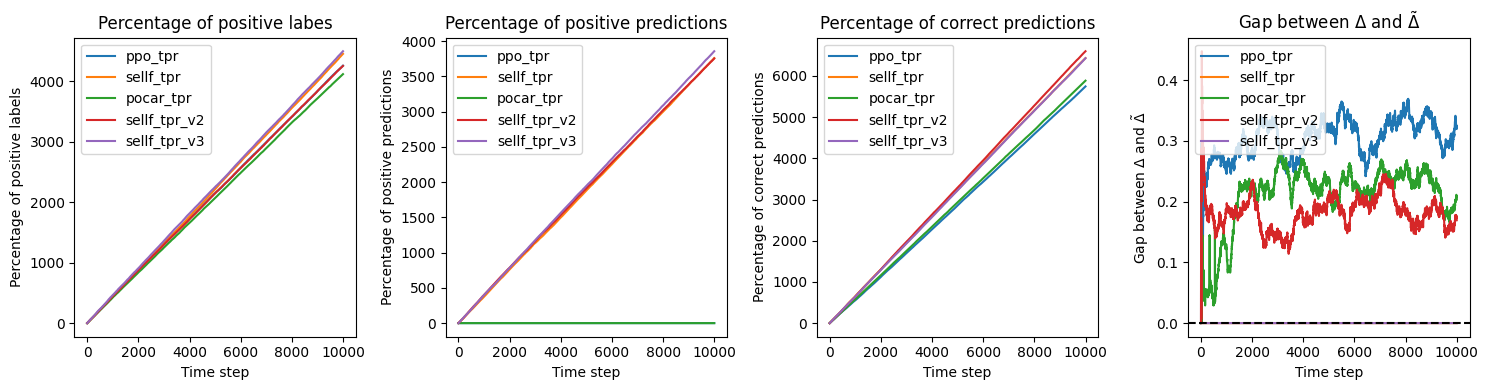

         method     C obs    C real    C diff
0       ppo_tpr  0.000520  0.303880  0.303360
1     sellf_tpr  0.000500  0.000500  0.000000
2     pocar_tpr  0.000520  0.209701  0.209181
3  sellf_tpr_v2  0.009444  0.191255  0.181811
4  sellf_tpr_v3  0.000320  0.000320  0.000000


In [337]:
plot_correct_predictions(data)

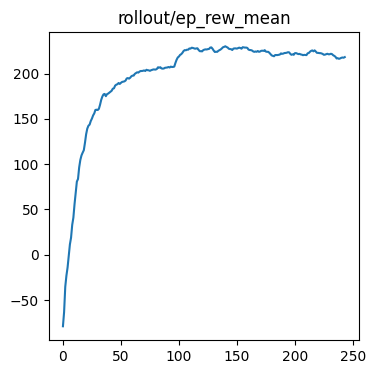

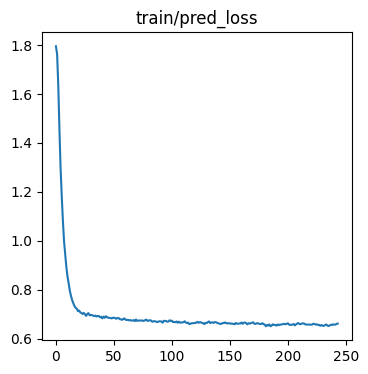

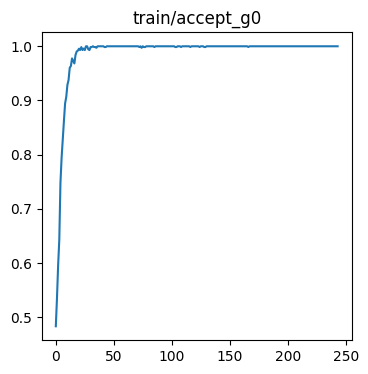

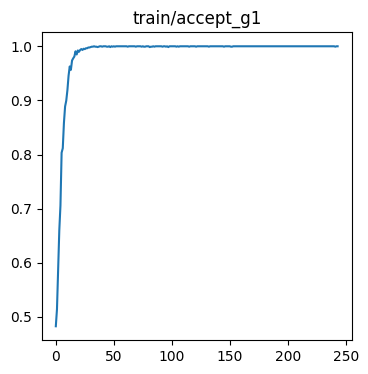

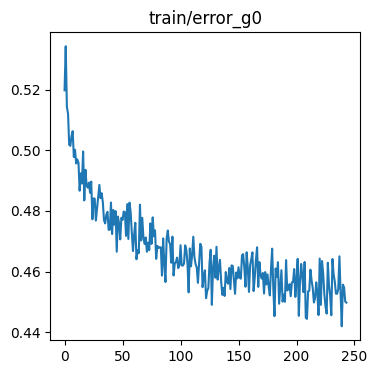

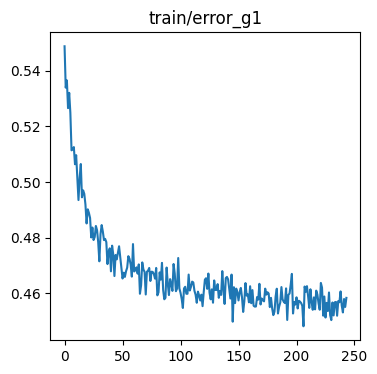

In [338]:
df_log = pd.read_csv("experiments/enem/sellf_tpr_v3/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    "train/accept_g0",
    "train/accept_g1",
    "train/error_g0",
    "train/error_g1",
]

for col in columns:
    fig = plt.figure(figsize=(4, 4))

    val = df_log[col].values
    # if there is a nan value, replace it with the previous value
    new_val = []
    for i in range(1, len(val)):
        if np.isnan(val[i]):
            new_val.append(new_val[-1])
        else:
            new_val.append(val[i])
    
    plt.plot(new_val, label=col)
    plt.title(col)
    plt.show()


## yu2022

In [458]:
env = "yu2022"
model_list = ["pocar_full",  "pocar", "sellf", "ppo"] # "sellf_v3",
model_folders = [f"experiments/{env}/{model}/eval/eval_data.csv" for model in model_list]
data = {}
for folder in model_folders:
    model_name = folder.split("/")[-3]
    data[model_name] = pd.read_csv(folder)

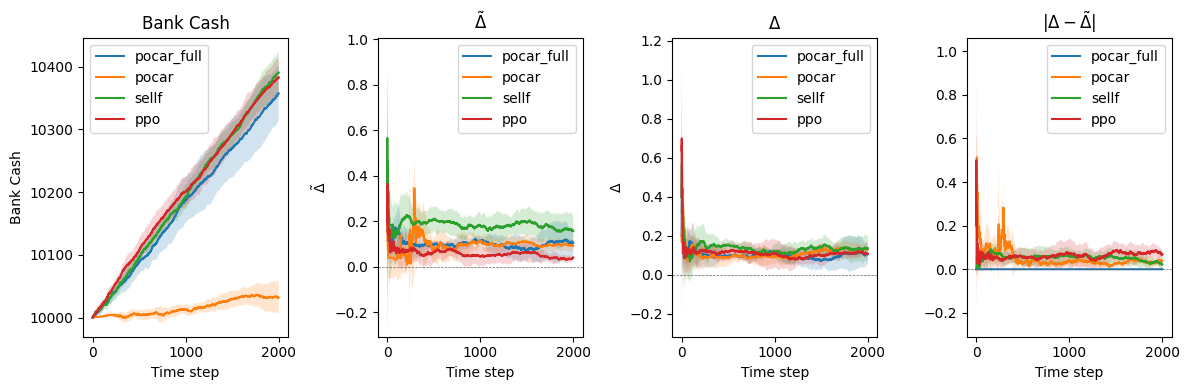

In [459]:
plot_results(data)

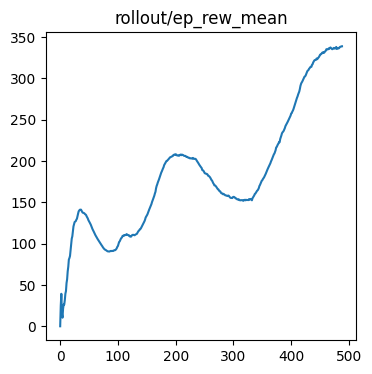

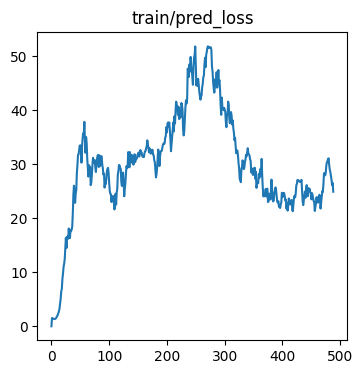

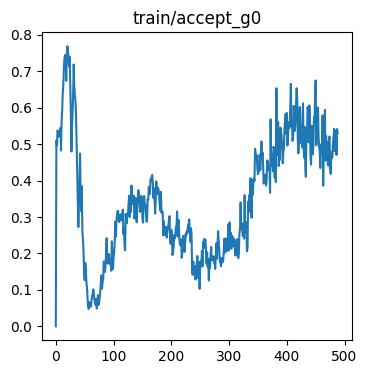

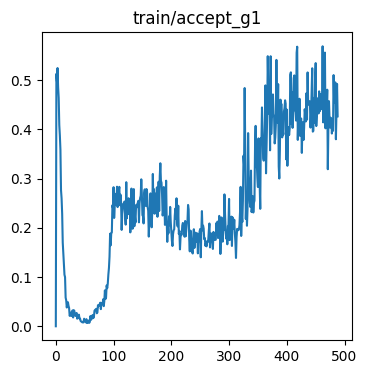

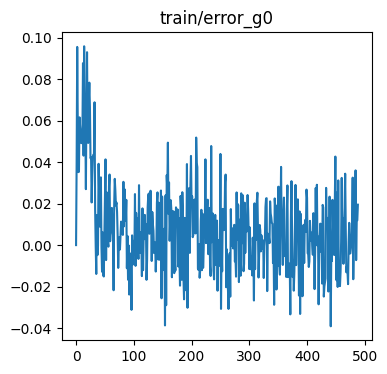

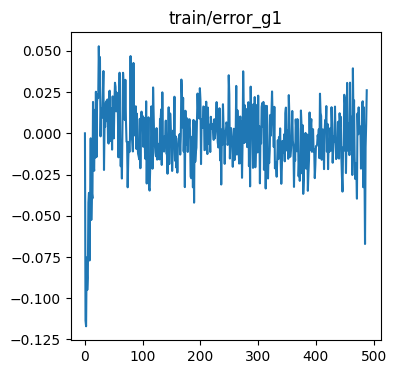

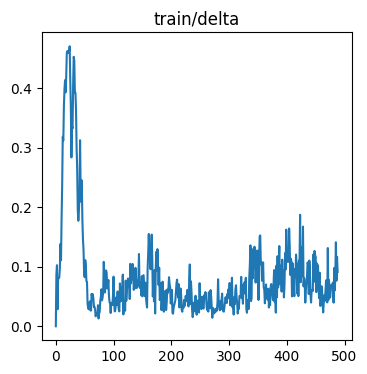

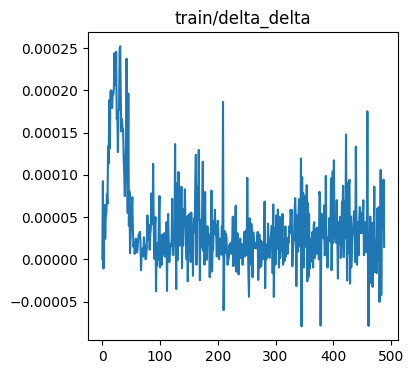

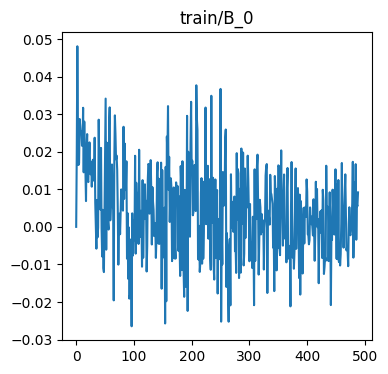

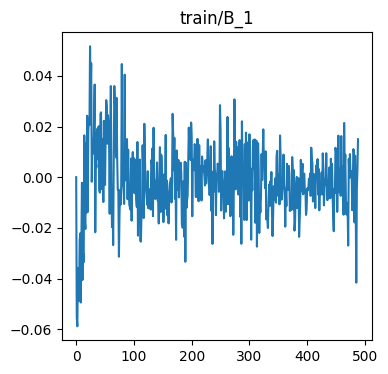

In [460]:
df_log = pd.read_csv("experiments/yu2022/sellf/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    "train/accept_g0",
    "train/accept_g1",
    "train/error_g0",
    "train/error_g1",
    "train/delta",
    "train/delta_delta",
    "train/B_0",
    "train/B_1",
]

for col in columns:
    try:
        fig = plt.figure(figsize=(4, 4))

        val = df_log[col].values
        # if there is a nan value, replace it with the previous value
        new_val = [0]
        for i in range(1, len(val)):
            if np.isnan(val[i]):
                new_val.append(new_val[-1])
            else:
                new_val.append(val[i])
        
        plt.plot(new_val, label=col)
        plt.title(col)
        plt.show()
    except:
        print(f"Error plotting {col}")
        continue


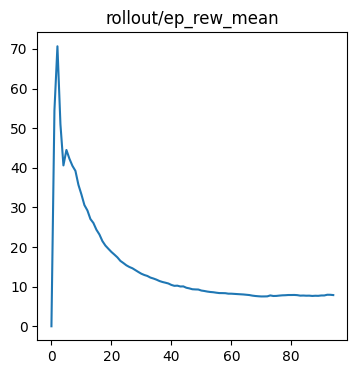

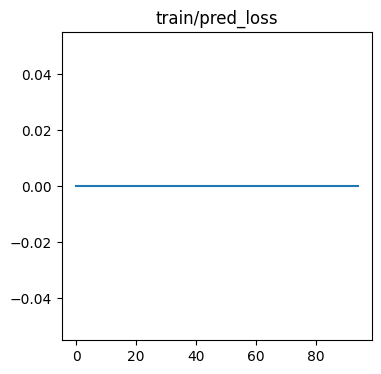

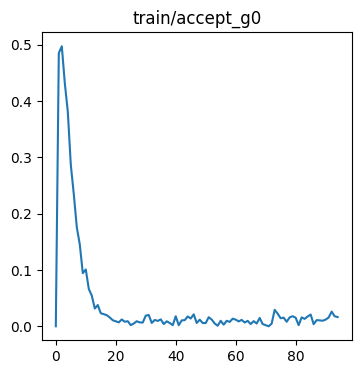

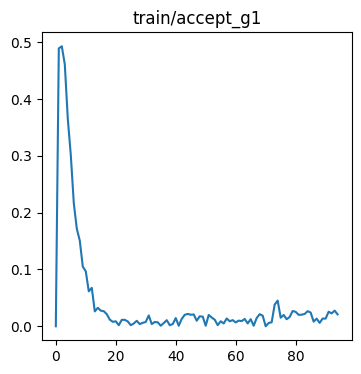

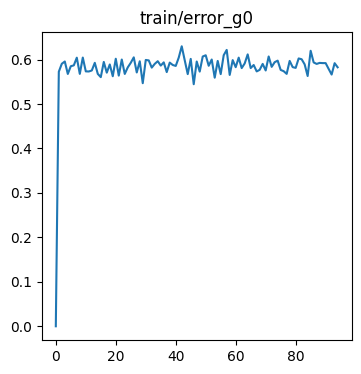

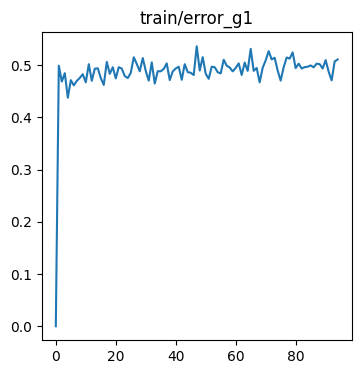

In [402]:
df_log = pd.read_csv("experiments/yu2022/pocar_full/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    "train/accept_g0",
    "train/accept_g1",
    "train/error_g0",
    "train/error_g1",
]

for col in columns:
    fig = plt.figure(figsize=(4, 4))

    val = df_log[col].values
    # if there is a nan value, replace it with the previous value
    new_val = [0]
    for i in range(1, len(val)):
        if np.isnan(val[i]):
            new_val.append(new_val[-1])
        else:
            new_val.append(val[i])
    
    plt.plot(new_val, label=col)
    plt.title(col)
    plt.show()


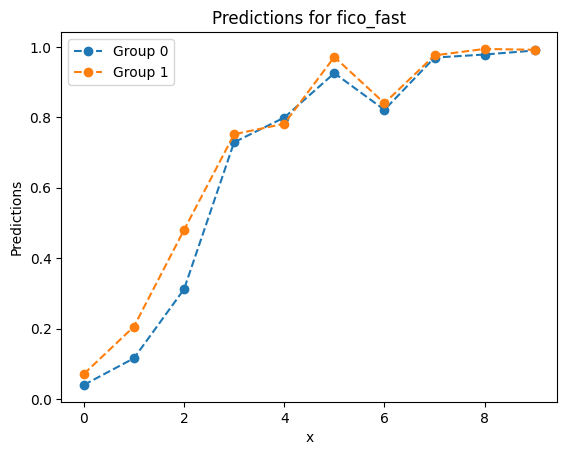

In [346]:
for env in ["fico_fast"]:
    preds = {}
    model_folders = glob(f"experiments/{env}/sellf_v3/eval/predictions.csv")
    for folder in model_folders:
        model_name = folder.split("/")[-3]
        preds[model_name] = pd.read_csv(folder)

    for df in preds.values():
        for g in range(2):
            df_ = df[df.g == g]
            df_ = df_.sort_values("x")
            plt.plot(df_.x, df_.pred, label=f"Group {g}", marker="o", linestyle="--")
    plt.title(f"Predictions for {env}")
    plt.xlabel("x")
    plt.ylabel("Predictions")
    plt.legend()
    plt.show()